# Linear-Elastic Plate with Hole — Provenance Plots

This notebook fetches benchmark provenance data from RoHub and visualises how the simulation results depend on the mesh element size and the polynomial degree of the isoparametric elements.

Each series in the plots corresponds to one combination of simulation tool and element degree. The x-axis uses a logarithmic scale; error plots additionally use a logarithmic y-axis so that convergence rates appear as straight lines.

## Setup

Import the helper functions from the `provenance` package.

In [6]:
import os
import sys

provenance_path = os.path.abspath(os.path.join("..", "provenance"))

if provenance_path not in sys.path:
    sys.path.append(provenance_path)

from plot_metrics import parse_args, run

## Configuration

The `make_args` helper builds the argument list passed to `parse_args`. Set `log_y=True` for metrics where a logarithmic y-axis is appropriate (i.e. error norms).

## Configuration

The `make_args` helper builds the argument list passed to `parse_args`. Set `log_y=True` for metrics where a logarithmic y-axis is appropriate (i.e. error norms).

In [7]:
BENCHMARK_NAME = "linear-elastic-plate-with-hole"


def make_args(y_axis_label, plot_title, log_y=False):
    cli_args = [
        "--benchmark-name", BENCHMARK_NAME,
        "--x-axis-label", "Element Size",
        "--y-axis-label", y_axis_label,
        "--plot-title", plot_title,
       "--use-production-rohub", True, # Use the option for the production hub once provenance data is available there.
       "--log-y", log_y,
    ]

    if log_y:
        cli_args.append("--log-y")

    return parse_args(cli_args)


## Maximum von Mises Stress

Plot the maximum von Mises stress against the element size. A finer mesh generally resolves stress concentrations more accurately, so the value is expected to increase and converge towards the analytical solution as the element size decreases.

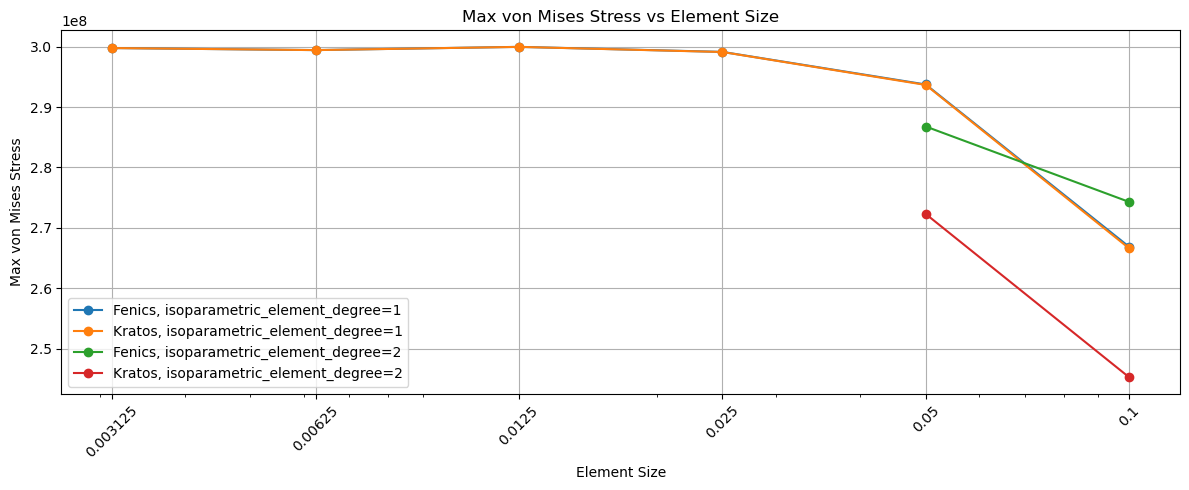

In [8]:
parameters = ["element_size", "isoparametric_element_degree"]
metrics = ["max_von_mises_stress"]
args = make_args(
    y_axis_label="Max von Mises Stress",
    plot_title="Max von Mises Stress vs Element Size",
)

run(args, parameters, metrics)


## Maximum Displacement Error

Plot the maximum displacement error against the element size on a log–log scale. For a well-converging method the error decreases as a power of the element size, appearing as a straight line whose slope equals the convergence rate.

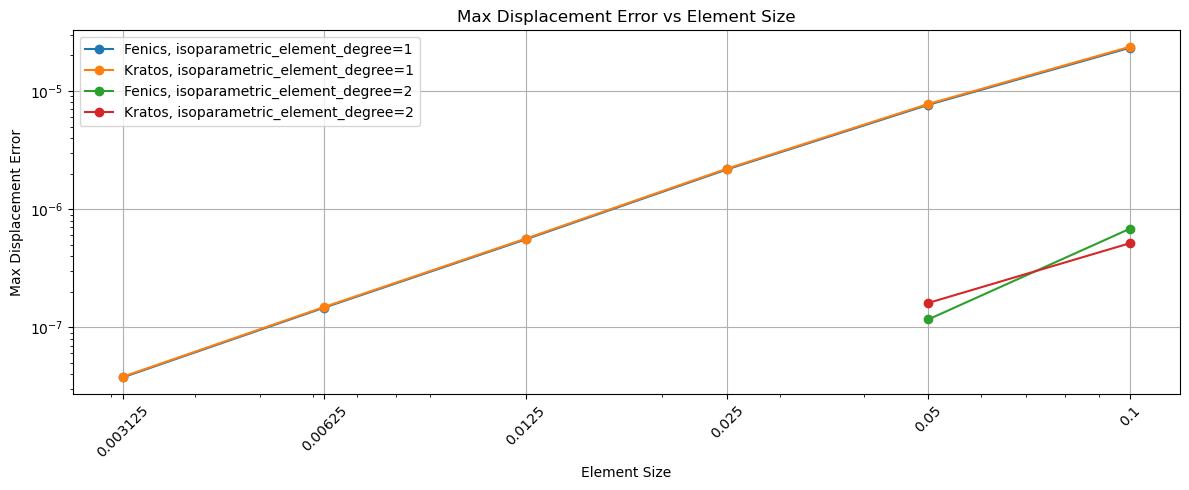

In [9]:
parameters = ["element_size", "isoparametric_element_degree"]
metrics = ["max_displacement_error"]
args = make_args(
    y_axis_label="Max Displacement Error",
    plot_title="Max Displacement Error vs Element Size",
    log_y=True,
)

run(args, parameters, metrics)


## L2 Displacement Error

Plot the L2 norm of the displacement error against the element size on a log–log scale. The L2 error averages the error over the whole domain.

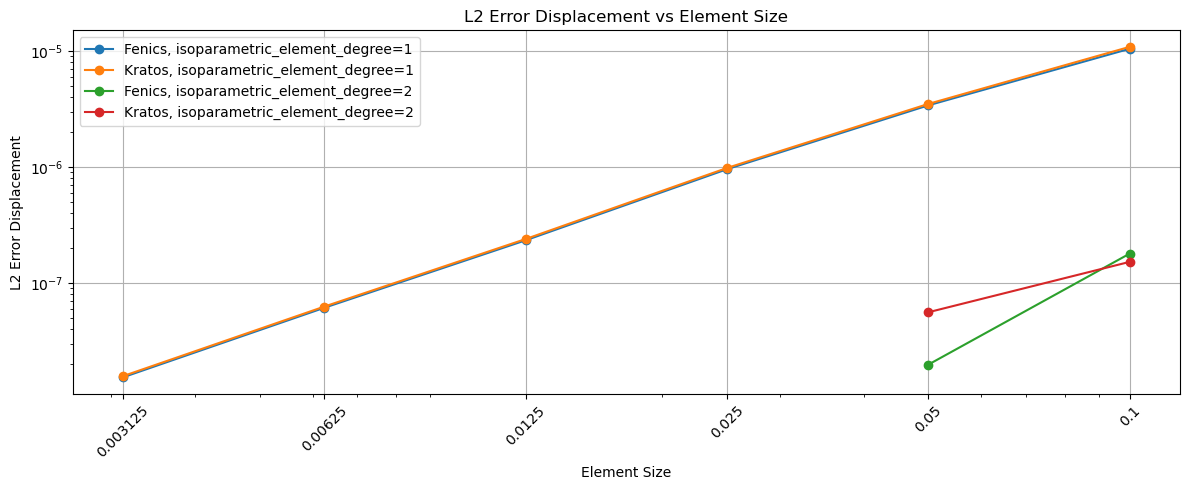

In [10]:
parameters = ["element_size", "isoparametric_element_degree"]
metrics = ["l2_error_displacement"]
args = make_args(
    y_axis_label="L2 Error Displacement",
    plot_title="L2 Error Displacement vs Element Size",
    log_y=True,
)

run(args, parameters, metrics)
